# CLTV y Acciones Comerciales — Churn Prediction
**Universidad Alfonso X el Sabio (UAX)**


En este notebook calculamos el **Customer Lifetime Value (CLTV)** de cada nuevo cliente, los segmentamos por riesgo y valor, y diseñamos acciones comerciales concretas con su correspondiente análisis de rentabilidad (ROI).


## 1. Librerías y configuración visual


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'
UAX_GOLD    = '#C8A951'
UAX_LIGHT   = '#E8E0D0'
UAX_GREY    = '#6B7B8D'
UAX_ACCENT  = '#3A5BA0'
UAX_RED     = '#C0392B'
UAX_GREEN   = '#27AE60'

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})
sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ Configuración visual UAX cargada


## 2. Carga de datos


In [2]:
# Tabla de costes por modelo
costes = pd.read_csv('data/lake/costes.csv')
display(costes)

# Nuevos clientes con predicciones del notebook anterior
new_customers = pd.read_csv('data/lake/nuevos_clientes.csv')
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in new_customers.columns:
        new_customers[col] = pd.to_datetime(new_customers[col], errors='coerce', dayfirst=True, format='%d/%m/%Y')

# Cargar modelo y threshold
xgboost_model  = joblib.load('data/warehouse/xgboost.pkl')
full_pipeline  = joblib.load('data/warehouse/num_pipeline.pkl')
BEST_THRESHOLD = joblib.load('data/warehouse/best_threshold.pkl')

print(f'Nuevos clientes: {new_customers.shape[0]:,}')
print(f'Modelos en tabla de costes: {costes["Modelo"].tolist()}')


,Modelo,Margen,Costetransporte,Margendistribuidor,GastosMarketing,Mantenimiento_medio,Comisión_Marca
0,A,28.0,250.0,5.0,5.0,250.0,2.0
1,B,33.0,250.0,5.0,5.0,263.0,2.0
2,C,33.0,250.0,5.0,25.0,276.0,5.0
3,D,33.0,250.0,5.0,25.0,290.0,5.0
4,E,37.0,250.0,5.0,25.0,305.0,5.0
5,F,42.0,250.0,5.0,25.0,320.0,5.0
6,G,42.0,250.0,5.0,25.0,336.0,5.0
7,H,42.0,250.0,5.0,25.0,353.0,5.0
8,I,43.0,250.0,5.0,5.0,371.0,8.0
9,J,5.0,250.0,5.0,25.0,390.0,8.0


Nuevos clientes: 10,000
Modelos en tabla de costes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


## 3. Obtener probabilidades de churn


In [3]:
# Alinear esquema (mismo proceso que en model_verification)
rename_map = {'Lead_compra_1': 'Fue_Lead'}
new_customers = new_customers.rename(columns={k: v for k, v in rename_map.items() if k in new_customers.columns})

# Cargar test_set para referencia de columnas
test_set = pd.read_csv('data/warehouse/test_set.csv')
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in test_set.columns:
        test_set[col] = pd.to_datetime(test_set[col], errors='coerce')

if 'Churn_400' not in new_customers.columns:
    new_customers['Churn_400'] = 'N'
if 'DAYS_LAST_SERVICE' not in new_customers.columns:
    new_customers['DAYS_LAST_SERVICE'] = np.nan

extra_cols = set(new_customers.columns) - set(test_set.columns)
if extra_cols:
    new_customers = new_customers.drop(columns=extra_cols)

missing_cols = set(test_set.columns) - set(new_customers.columns)
for col in missing_cols:
    new_customers[col] = np.nan

new_customers = new_customers[test_set.columns]

# Transformar y predecir
new_prepared = full_pipeline.fit_transform(new_customers)
if 'Churn_400' in new_prepared.columns:
    X_new = new_prepared.drop(columns=['Churn_400'])
else:
    X_new = new_prepared

new_proba = xgboost_model.predict_proba(X_new)[:, 1]

# Construir dataframe de trabajo
df = new_prepared.copy()
df['p_churn'] = new_proba
df['CODE'] = new_customers.loc[new_prepared.index, 'CODE'].values
df['Modelo_letra'] = new_customers.loc[new_prepared.index, 'Modelo'].values
df['Id_Producto'] = new_customers.loc[new_prepared.index, 'Id_Producto'].values
df['PVP_original'] = new_customers.loc[new_prepared.index, 'PVP'].values

print(f'Clientes con predicción: {len(df):,}')
print(f'P(churn) media: {df["p_churn"].mean():.4f}')
print(f'Modelos presentes: {sorted(df["Modelo_letra"].unique())}')


Clientes con predicción: 10,000
P(churn) media: 0.2990
Modelos presentes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


## 4. Cálculo del CLTV (Customer Lifetime Value)


### Fórmula del coste de mantenimiento

El ingreso por la revisión `n` de un cliente es:

**C(n) = BASE × (1 + α)^n**

Donde:
- `BASE` = Mantenimiento_medio de la tabla de costes según el modelo del coche
- α = 7% para modelos A y B, 10% para el resto
- n = número de revisión (empezamos en n=1 para los nuevos clientes)

### Costes fijos por revisión
- 1% Marketing
- 30% Costes fijos
- 7% Comisión de marca
- **Total: 38% del ingreso bruto**

### Beneficio neto por revisión
**Beneficio(n) = C(n) × 0.62**

### CLTV con probabilidad de supervivencia
Para incorporar el riesgo de churn, cada revisión futura se pondera por la probabilidad de que el cliente siga activo:

**CLTV = Σ (n=1 hasta N) [ Beneficio(n) × (1 − p_churn)^n ]**

Un cliente con alta probabilidad de churn verá su CLTV reducido porque es probable que se vaya antes de las revisiones más caras.


In [4]:
# ── Parámetros ───────────────────────────────────────────────
HORIZONTE_REVISIONES = 10   # simulamos hasta 10 revisiones futuras
COSTES_FIJOS_PCT     = 0.38 # 1% marketing + 30% fijos + 7% comisión
MARGEN_NETO_PCT      = 1 - COSTES_FIJOS_PCT  # 0.62

# Alpha por modelo
ALPHA_AB    = 0.07
ALPHA_RESTO = 0.10

# Mapear BASE (Mantenimiento_medio) y alpha por modelo
costes_dict = costes.set_index('Modelo')['Mantenimiento_medio'].to_dict()

def get_alpha(modelo):
    return ALPHA_AB if modelo in ['A', 'B'] else ALPHA_RESTO

def calcular_cltv(row):
    modelo = row['Modelo_letra']
    p_churn = row['p_churn']
    base = costes_dict.get(modelo, 300)  # fallback si modelo no existe
    alpha = get_alpha(modelo)
    
    cltv = 0
    desglose = []
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso_bruto = base * (1 + alpha) ** n
        beneficio_neto = ingreso_bruto * MARGEN_NETO_PCT
        prob_supervivencia = (1 - p_churn) ** n
        beneficio_ponderado = beneficio_neto * prob_supervivencia
        cltv += beneficio_ponderado
        desglose.append({
            'n': n,
            'ingreso_bruto': ingreso_bruto,
            'beneficio_neto': beneficio_neto,
            'p_supervivencia': prob_supervivencia,
            'beneficio_ponderado': beneficio_ponderado,
        })
    
    return cltv

# Calcular CLTV para cada cliente
df['CLTV'] = df.apply(calcular_cltv, axis=1)

print(f'CLTV medio: {df["CLTV"].mean():,.0f} €')
print(f'CLTV mediano: {df["CLTV"].median():,.0f} €')
print(f'Rango: {df["CLTV"].min():,.0f} € — {df["CLTV"].max():,.0f} €')


CLTV medio: 847 €
CLTV mediano: 555 €
Rango: 56 € — 3,462 €


### 4.1 Ejemplo detallado: desglose de revisiones


In [5]:
# Ejemplo con un cliente de modelo D (α=10%, BASE=290€)
ejemplo_base = 290
ejemplo_alpha = 0.10
ejemplo_pchurn_bajo = 0.03
ejemplo_pchurn_alto = 0.15

rows = []
for n in range(1, HORIZONTE_REVISIONES + 1):
    ingreso = ejemplo_base * (1 + ejemplo_alpha) ** n
    benef = ingreso * MARGEN_NETO_PCT
    surv_bajo = (1 - ejemplo_pchurn_bajo) ** n
    surv_alto = (1 - ejemplo_pchurn_alto) ** n
    rows.append({
        'Revisión': n,
        'Ingreso bruto': f'{ingreso:,.0f} €',
        'Beneficio neto': f'{benef:,.0f} €',
        'P(activo) bajo riesgo': f'{surv_bajo:.1%}',
        'P(activo) alto riesgo': f'{surv_alto:.1%}',
        'CLTV acum. bajo': f'{benef * surv_bajo:,.0f} €',
        'CLTV acum. alto': f'{benef * surv_alto:,.0f} €',
    })

df_ejemplo = pd.DataFrame(rows)
display(df_ejemplo)


,Revisión,Ingreso bruto,Beneficio neto,P(activo) bajo riesgo,P(activo) alto riesgo,CLTV acum. bajo,CLTV acum. alto
0,1,319 €,198 €,97.0%,85.0%,192 €,168 €
1,2,351 €,218 €,94.1%,72.2%,205 €,157 €
2,3,386 €,239 €,91.3%,61.4%,218 €,147 €
3,4,425 €,263 €,88.5%,52.2%,233 €,137 €
4,5,467 €,290 €,85.9%,44.4%,249 €,128 €
5,6,514 €,319 €,83.3%,37.7%,265 €,120 €
6,7,565 €,350 €,80.8%,32.1%,283 €,112 €
7,8,622 €,385 €,78.4%,27.2%,302 €,105 €
8,9,684 €,424 €,76.0%,23.2%,322 €,98 €
9,10,752 €,466 €,73.7%,19.7%,344 €,92 €


Se ve claramente cómo el cliente de alto riesgo pierde valor en cada revisión futura: aunque los precios suben (por el factor α), la probabilidad de que siga viniendo baja mucho más rápido.


### 4.2 Distribución del CLTV


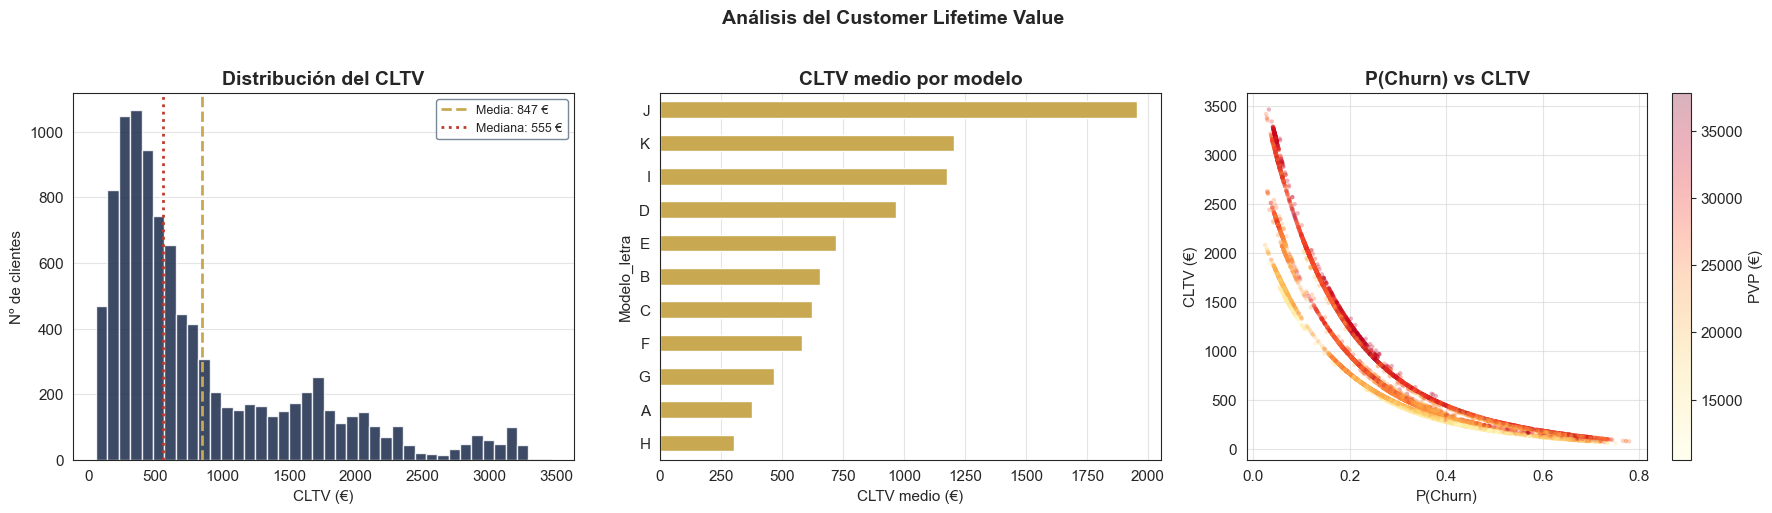

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma general
ax = axes[0]
ax.hist(df['CLTV'], bins=40, color=UAX_NAVY, edgecolor='white', alpha=0.85)
ax.axvline(df['CLTV'].mean(), color=UAX_GOLD, linestyle='--', lw=2, label=f'Media: {df["CLTV"].mean():,.0f} €')
ax.axvline(df['CLTV'].median(), color=UAX_RED, linestyle=':', lw=2, label=f'Mediana: {df["CLTV"].median():,.0f} €')
ax.set_xlabel('CLTV (€)')
ax.set_ylabel('Nº de clientes')
ax.set_title('Distribución del CLTV')
ax.legend(fontsize=9)
ax.grid(axis='y')

# CLTV por modelo
ax = axes[1]
cltv_by_model = df.groupby('Modelo_letra')['CLTV'].mean().sort_values()
cltv_by_model.plot(kind='barh', color=UAX_GOLD, edgecolor='white', ax=ax)
ax.set_xlabel('CLTV medio (€)')
ax.set_title('CLTV medio por modelo')
ax.grid(axis='x')

# Scatter: p_churn vs CLTV
ax = axes[2]
scatter = ax.scatter(df['p_churn'], df['CLTV'], c=df['PVP_original'], cmap='YlOrRd',
                     alpha=0.3, s=10, edgecolors='none')
ax.set_xlabel('P(Churn)')
ax.set_ylabel('CLTV (€)')
ax.set_title('P(Churn) vs CLTV')
plt.colorbar(scatter, ax=ax, label='PVP (€)')
ax.grid(True)

plt.suptitle('Análisis del Customer Lifetime Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Segmentación: Riesgo × Valor


Creamos una matriz de segmentación cruzando dos dimensiones:
- **Riesgo de churn**: basado en la probabilidad predicha (quintiles) → 5 niveles
- **Valor del cliente**: basado en el CLTV calculado (percentiles) → 3 niveles

Esto genera **15 segmentos** con estrategias diferenciadas, permitiendo mayor granularidad táctica que una segmentación 3×3.

In [7]:
# ── Definir segmentos ────────────────────────────────────────
# Riesgo: basado en quintiles de p_churn → 5 grupos
df['riesgo'] = pd.qcut(df['p_churn'], q=5,
                        labels=['MUY_BAJO', 'BAJO', 'MEDIO', 'ALTO', 'MUY_ALTO'])

# Valor: basado en percentiles de CLTV → 3 grupos
df['valor'] = pd.qcut(df['CLTV'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Segmento combinado
df['segmento'] = df['riesgo'].astype(str) + ' riesgo / ' + df['valor'].astype(str) + ' valor'

print('Distribución de segmentos:')
print(df.groupby(['riesgo', 'valor']).size().unstack(fill_value=0))
print(f'\nTotal clientes segmentados: {len(df):,}')


Distribución de segmentos:
valor     Bajo  Medio  Alto
riesgo                     
MUY_BAJO     0      0  2000
BAJO         0    764  1236
MEDIO       13   1889    98
ALTO      1320    680     0
MUY_ALTO  2000      0     0

Total clientes segmentados: 10,000


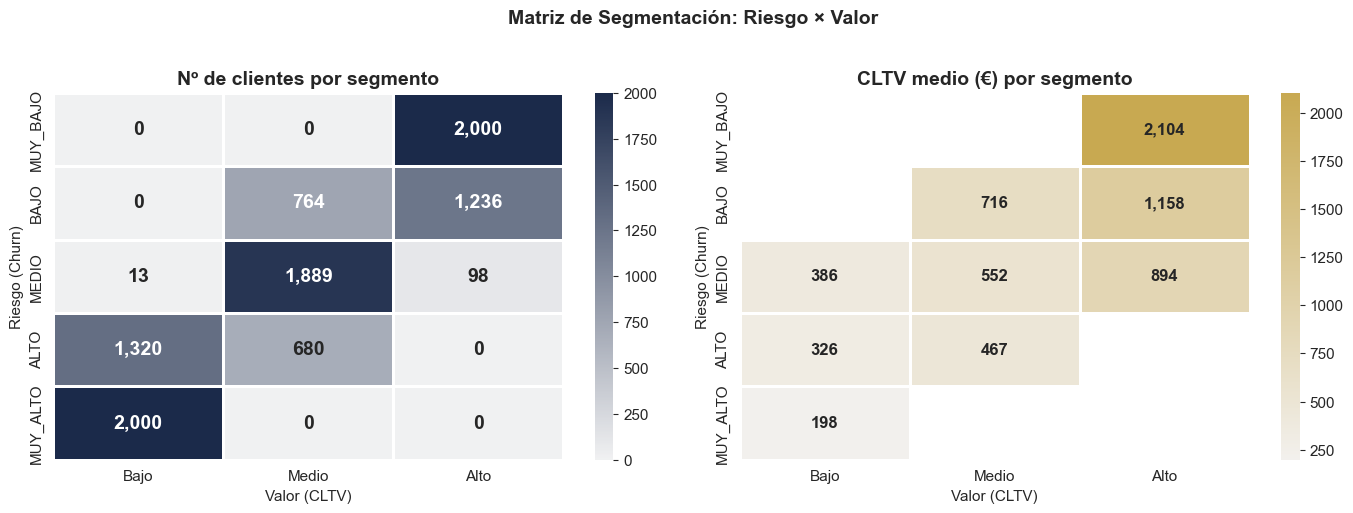

In [8]:
# Visualización de la matriz
pivot_count = df.groupby(['riesgo', 'valor']).size().unstack(fill_value=0)
pivot_cltv  = df.groupby(['riesgo', 'valor'])['CLTV'].mean().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
ax = axes[0]
sns.heatmap(pivot_count, annot=True, fmt=',d', cmap=sns.light_palette(UAX_NAVY, as_cmap=True),
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title('Nº de clientes por segmento')
ax.set_xlabel('Valor (CLTV)')
ax.set_ylabel('Riesgo (Churn)')

# CLTV medio
ax = axes[1]
sns.heatmap(pivot_cltv, annot=True, fmt=',.0f', cmap=sns.light_palette(UAX_GOLD, as_cmap=True),
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('CLTV medio (€) por segmento')
ax.set_xlabel('Valor (CLTV)')
ax.set_ylabel('Riesgo (Churn)')

plt.suptitle('Matriz de Segmentación: Riesgo × Valor', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Asignación de acciones comerciales


### Reglas de negocio

Los paquetes de servicio reemplazan los descuentos genéricos por acciones operacionales con costes fijos reales:

| Riesgo | Valor | Acción | Servicios incluidos | Coste por respondedor |
|---|---|---|---|---|
| **MUY_ALTO** | Alto / Medio | Contacto prioritario | Bono 20€ | 20€ |
| **MUY_ALTO** | Bajo | Contacto mínimo | Email de seguimiento | 0€ |
| **ALTO** | Alto / Medio | Pack Premium VIP | Recogida (35€) + Lavado int./ext. (30€) + Cambio neumáticos (35€) + Bono 50€ | **150€** |
| **ALTO** | Bajo | Contacto mínimo | Email de seguimiento | 0€ |
| **MEDIO** | Alto / Medio | Pack Intermedio | Regalo (6€) + Lavado (30€) + Bono 30€ | **66€** |
| **MEDIO** | Bajo | Seguimiento estándar | Recordatorio de revisión | 0€ |
| **BAJO** | Alto | Upselling | Oferta ext. garantía / seguro batería | 0€ |
| **BAJO** | Medio | Mantenimiento | Comunicación periódica | 0€ |
| **BAJO** | Bajo | Sin acción | — | 0€ |
| **MUY_BAJO** | Alto | Upselling | Oferta ext. garantía / seguro batería | 0€ |
| **MUY_BAJO** | Medio | Mantenimiento | Comunicación periódica | 0€ |
| **MUY_BAJO** | Bajo | Sin acción | — | 0€ |

> El coste por respondedor se multiplica por la TR del segmento para obtener el coste efectivo por cliente en cartera.

Además, para clientes con **n ≥ 5 revisiones** y CLTV medio-alto se aplica un **descuento de 1.000€ en segundo vehículo**.

In [9]:
# ── Costes fijos de los paquetes de servicio (por respondedor) ─
# Separamos en dos componentes para el desglose de A5:
#   coste_adicional → servicios físicos (recogida, lavado, neumáticos, regalo)
#   coste_descuento → bono fijo en euros

# Pack Premium VIP: recogida(35) + lavado(30) + neumáticos(35) = 100€ adicional + bono 50€
# Pack Intermedio:  regalo(6) + lavado(30) = 36€ adicional + bono 30€
# Contacto prioritario: sin servicio + bono 20€

def asignar_accion(row):
    r = row['riesgo']
    v = row['valor']

    if r == 'MUY_ALTO':
        if v in ['Alto', 'Medio']:
            return 'Contacto prioritario', 0, 20, 'Bono 20€'
        else:
            return 'Contacto mínimo', 0, 0, 'Email de seguimiento'
    elif r == 'ALTO':
        if v in ['Alto', 'Medio']:
            return 'Pack Premium VIP', 100, 50, 'Recogida + lavado + neumáticos + bono 50€'
        else:
            return 'Contacto mínimo', 0, 0, 'Email de seguimiento'
    elif r == 'MEDIO':
        if v in ['Alto', 'Medio']:
            return 'Pack Intermedio', 36, 30, 'Regalo + lavado + bono 30€'
        else:
            return 'Seguimiento estándar', 0, 0, 'Recordatorio de revisión'
    else:  # BAJO o MUY_BAJO
        if v == 'Alto':
            return 'Upselling', 0, 0, 'Oferta ext. garantía / seguro batería'
        elif v == 'Medio':
            return 'Mantenimiento', 0, 0, 'Comunicación periódica'
        else:
            return 'Sin acción', 0, 0, '—'

acciones = df.apply(asignar_accion, axis=1, result_type='expand')
df['accion']             = acciones[0]
df['coste_adicional']    = acciones[1]   # servicios físicos por respondedor
df['coste_descuento']    = acciones[2]   # bono por respondedor
df['descripcion_accion'] = acciones[3]
df['coste_accion']       = df['coste_adicional'] + df['coste_descuento']  # total por respondedor

print('Distribución de acciones:')
resumen_acciones = df.groupby('accion').agg(
    clientes=('CODE', 'count'),
    coste_por_respondedor=('coste_accion', 'mean'),
    coste_bruto_total=('coste_accion', 'sum'),
    CLTV_medio=('CLTV', 'mean'),
    p_churn_medio=('p_churn', 'mean'),
).sort_values('coste_bruto_total', ascending=False)

resumen_acciones['coste_por_respondedor'] = resumen_acciones['coste_por_respondedor'].round(0)
resumen_acciones['coste_bruto_total']     = resumen_acciones['coste_bruto_total'].round(0)
resumen_acciones['CLTV_medio']            = resumen_acciones['CLTV_medio'].round(0)
resumen_acciones['p_churn_medio']         = resumen_acciones['p_churn_medio'].round(4)

display(resumen_acciones)


Distribución de acciones:


,clientes,coste_por_respondedor,coste_bruto_total,CLTV_medio,p_churn_medio
accion,,,,,
Pack Intermedio,1987,66.0,131142,569.0,0.2895
Pack Premium VIP,680,150.0,102000,467.0,0.3608
Contacto mínimo,3320,0.0,0,249.0,0.4799
Mantenimiento,764,0.0,0,716.0,0.2247
Seguimiento estándar,13,0.0,0,386.0,0.3256
Upselling,3236,0.0,0,1743.0,0.1237


In [10]:
# ── Tasa de respuesta (TR) por segmento de riesgo ────────────
# Solo el TR% de los clientes contactados responde y recibe el servicio.
TASA_RESPUESTA = {
    'MUY_ALTO': 0.10,   # Muy difíciles de recuperar — baja receptividad
    'ALTO':     0.80,   # Campaña premium VIP → alta efectividad
    'MEDIO':    0.55,   # Respuesta moderada
    'BAJO':     0.45,   # Baja urgencia percibida
    'MUY_BAJO': 0.40,   # Sin motivación para actuar
}

# ── Coste de contacto por canal (aplica al 100% de clientes) ─
COSTE_CONTACTO = {
    'MUY_ALTO': 0.20,   # Email básico
    'ALTO':     0.10,   # Email personalizado
    'MEDIO':    0.50,   # SMS personalizado
    'BAJO':     0.50,   # SMS
    'MUY_BAJO': 0.20,   # Email informativo
}

# .astype(float) necesario: df['riesgo'] es Categorical (pd.qcut) y .map() hereda ese dtype
df['tasa_respuesta'] = df['riesgo'].map(TASA_RESPUESTA).astype(float)
df['coste_contacto'] = df['riesgo'].map(COSTE_CONTACTO).astype(float)

# Ingreso revisión 1 — necesario para coste de marketing (1% de ingreso bruto)
def coste_revision_n(modelo, n):
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    return base * (1 + alpha) ** n

df['ingreso_rev1'] = df['Modelo_letra'].apply(lambda m: coste_revision_n(m, 1))

print('Respondedores estimados y coste de contacto por segmento:')
tr_summary = df.groupby('riesgo', observed=True).agg(
    clientes=('CODE', 'count'),
    tasa_respuesta=('tasa_respuesta', 'first'),
    coste_contacto_unit=('coste_contacto', 'first'),
).reset_index()
tr_summary['respondedores_estimados'] = (
    tr_summary['clientes'] * tr_summary['tasa_respuesta']
).round(0).astype(int)
tr_summary['coste_contacto_total'] = (
    tr_summary['clientes'] * tr_summary['coste_contacto_unit']
).round(0).astype(int)
tr_summary['tasa_respuesta'] = tr_summary['tasa_respuesta'].map('{:.0%}'.format)
tr_summary['coste_contacto_unit'] = tr_summary['coste_contacto_unit'].map('{:.2f} €'.format)
display(tr_summary)


Respondedores estimados y coste de contacto por segmento:


,riesgo,clientes,tasa_respuesta,coste_contacto_unit,respondedores_estimados,coste_contacto_total
0,MUY_BAJO,2000,40%,0.20 €,800,400
1,BAJO,2000,45%,0.50 €,900,1000
2,MEDIO,2000,55%,0.50 €,1100,1000
3,ALTO,2000,80%,0.10 €,1600,200
4,MUY_ALTO,2000,10%,0.20 €,200,400


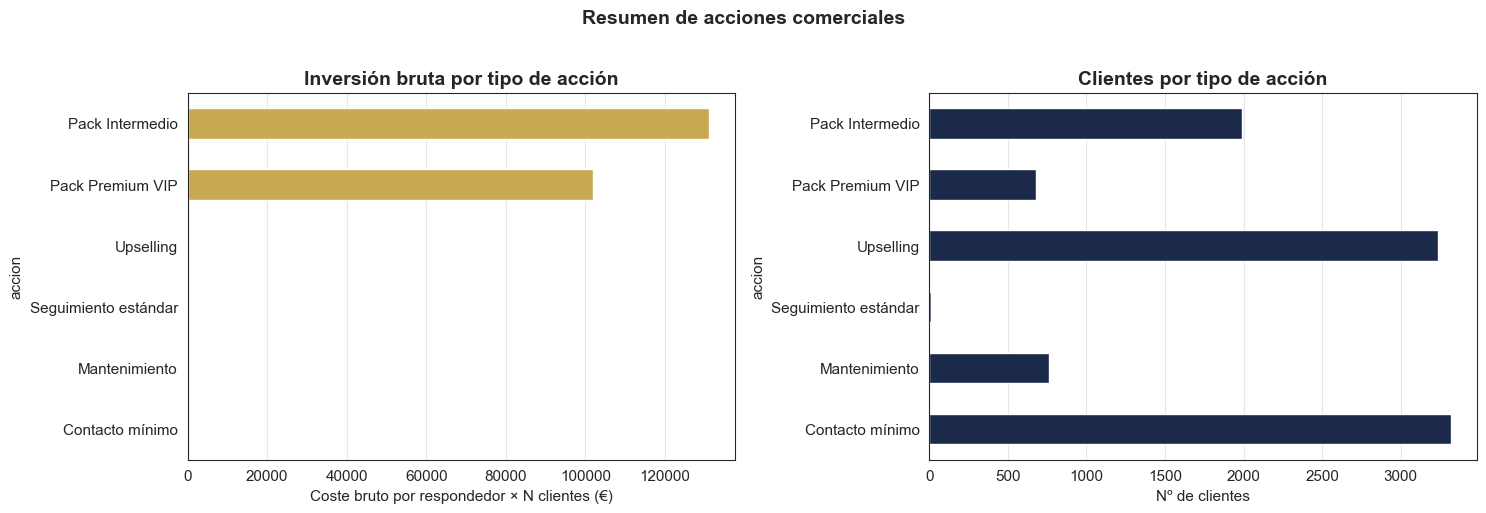

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coste bruto total por acción (antes de TR)
ax = axes[0]
resumen_plot = resumen_acciones.sort_values('coste_bruto_total')
resumen_plot['coste_bruto_total'].plot(kind='barh', color=UAX_GOLD, edgecolor='white', ax=ax)
ax.set_xlabel('Coste bruto por respondedor × N clientes (€)')
ax.set_title('Inversión bruta por tipo de acción')
ax.grid(axis='x')

# Clientes por acción
ax = axes[1]
resumen_plot['clientes'].plot(kind='barh', color=UAX_NAVY, edgecolor='white', ax=ax)
ax.set_xlabel('Nº de clientes')
ax.set_title('Clientes por tipo de acción')
ax.grid(axis='x')

plt.suptitle('Resumen de acciones comerciales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Simulación económica — ROI de las acciones


Simulamos el impacto de cada acción bajo dos supuestos combinados:

1. **Reducción de p_churn**: la acción reduce la probabilidad de abandono (solo para respondedores).
2. **Tasa de respuesta (TR)**: solo el TR% de clientes responde — ganancia y costes variables se ponderan por TR.

El coste total se desglosa en **4 componentes**:

| Componente | Aplica a | Descripción |
|---|---|---|
| `Coste_Contacto` | 100% clientes | Email/SMS de contacto (0.10–0.50€/cliente) |
| `Coste_Adicional` | TR% (respondedores) | Servicios físicos: recogida, lavado, neumáticos, regalo |
| `Coste_Descuento` | TR% (respondedores) | Bono fijo en euros |
| `Coste_Marketing` | TR% (respondedores) | 1% del ingreso bruto de la revisión 1 |

| Acción | Reducción estimada de p_churn |
|---|---|
| Pack Premium VIP | −40% |
| Pack Intermedio | −20% |
| Contacto prioritario | −15% |
| Upselling | −10% |
| Seguimiento / Contacto mínimo / Mantenimiento | −5% |
| Sin acción | 0% |

In [12]:
# ── Simulación de impacto ────────────────────────────────────
REDUCCION_CHURN = {
    'Pack Premium VIP':      0.40,
    'Pack Intermedio':       0.20,
    'Contacto prioritario':  0.15,
    'Upselling':             0.10,
    'Seguimiento estándar':  0.05,
    'Contacto mínimo':       0.05,
    'Mantenimiento':         0.05,
    'Sin acción':            0.00,
}

def calcular_cltv_con_pchurn(row, p_churn):
    modelo = row['Modelo_letra']
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    cltv = 0
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso_bruto = base * (1 + alpha) ** n
        beneficio_neto = ingreso_bruto * MARGEN_NETO_PCT
        prob_supervivencia = (1 - p_churn) ** n
        cltv += beneficio_neto * prob_supervivencia
    return cltv

df['CLTV_sin_accion'] = df['CLTV']

def cltv_post_accion(row):
    reduccion = REDUCCION_CHURN.get(row['accion'], 0)
    p_churn_new = row['p_churn'] * (1 - reduccion)
    return calcular_cltv_con_pchurn(row, p_churn_new)

df['CLTV_con_accion'] = df.apply(cltv_post_accion, axis=1)
df['ganancia_cltv_respondedor'] = df['CLTV_con_accion'] - df['CLTV_sin_accion']

# ── Desglose en 4 componentes de coste ───────────────────────
COSTE_MARKETING_PCT = 0.01   # 1% del ingreso bruto de rev1 por respondedor

df['coste_efectivo_contacto']  = df['coste_contacto']                           # 100% clientes
df['coste_efectivo_adicional'] = df['coste_adicional'] * df['tasa_respuesta']   # solo TR%
df['coste_efectivo_descuento'] = df['coste_descuento'] * df['tasa_respuesta']   # solo TR%
df['coste_efectivo_marketing'] = df['ingreso_rev1'] * COSTE_MARKETING_PCT * df['tasa_respuesta']

df['coste_accion'] = (
    df['coste_efectivo_contacto']
    + df['coste_efectivo_adicional']
    + df['coste_efectivo_descuento']
    + df['coste_efectivo_marketing']
)

# Ganancia efectiva ponderada por TR
df['ganancia_cltv'] = df['ganancia_cltv_respondedor'] * df['tasa_respuesta']

df['ROI'] = np.where(
    df['coste_accion'] > 0,
    (df['ganancia_cltv'] - df['coste_accion']) / df['coste_accion'],
    np.nan
)

print('=== DESGLOSE DE COSTES POR COMPONENTE ===')
print(f'  Contacto    (100% clientes):  {df["coste_efectivo_contacto"].sum():>10,.0f} €')
print(f'  Adicional   (servicios TR%):  {df["coste_efectivo_adicional"].sum():>10,.0f} €')
print(f'  Descuento   (bonos TR%):      {df["coste_efectivo_descuento"].sum():>10,.0f} €')
print(f'  Marketing   (1% rev1 TR%):    {df["coste_efectivo_marketing"].sum():>10,.0f} €')
print(f'  {"─"*40}')
print(f'  Inversión total:              {df["coste_accion"].sum():>10,.0f} €')
print()
print('=== RESUMEN ECONÓMICO ===')
print(f'  Ganancia de CLTV esperada:    {df["ganancia_cltv"].sum():>10,.0f} €')
print(f'  Beneficio neto:               {(df["ganancia_cltv"] - df["coste_accion"]).sum():>10,.0f} €')
print(f'  ROI medio (con coste):        {df.loc[df["coste_accion"] > 0, "ROI"].mean():>8.1f}x')


=== DESGLOSE DE COSTES POR COMPONENTE ===
  Contacto    (100% clientes):       3,000 €
  Adicional   (servicios TR%):      93,743 €
  Descuento   (bonos TR%):          59,986 €
  Marketing   (1% rev1 TR%):        15,021 €
  ────────────────────────────────────────
  Inversión total:                 171,749 €

=== RESUMEN ECONÓMICO ===
  Ganancia de CLTV esperada:       696,970 €
  Beneficio neto:                  525,221 €
  ROI medio (con coste):            10.9x


In [13]:
# Simulación por acción
sim = df.groupby('accion').agg(
    clientes=('CODE', 'count'),
    inversion=('coste_accion', 'sum'),
    ganancia_cltv=('ganancia_cltv', 'sum'),
    roi_medio=('ROI', 'mean'),
).round(0)

sim['beneficio_neto'] = sim['ganancia_cltv'] - sim['inversion']
sim = sim.sort_values('beneficio_neto', ascending=False)
display(sim)


,clientes,inversion,ganancia_cltv,roi_medio,beneficio_neto
accion,,,,,
Pack Premium VIP,680,83641.0,277957.0,2.0,194316.0
Upselling,3236,5949.0,152208.0,24.0,146259.0
Pack Intermedio,1987,76562.0,215655.0,2.0,139093.0
Contacto mínimo,3320,4186.0,35829.0,6.0,31643.0
Mantenimiento,764,1385.0,15098.0,10.0,13713.0
Seguimiento estándar,13,26.0,223.0,8.0,197.0


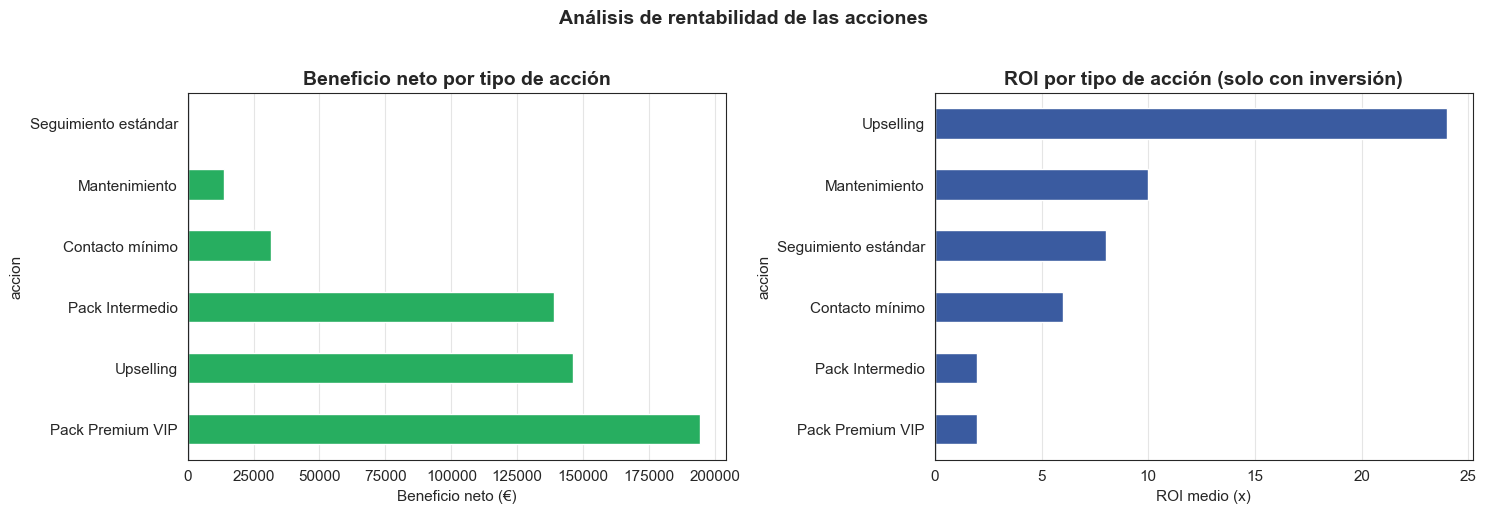

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Beneficio neto por acción
ax = axes[0]
colors_bn = [UAX_GREEN if v > 0 else UAX_RED for v in sim['beneficio_neto']]
sim['beneficio_neto'].plot(kind='barh', color=colors_bn, edgecolor='white', ax=ax)
ax.set_xlabel('Beneficio neto (€)')
ax.set_title('Beneficio neto por tipo de acción')
ax.axvline(x=0, color=UAX_GREY, linewidth=1)
ax.grid(axis='x')

# ROI por acción (solo las que tienen coste)
ax = axes[1]
roi_data = sim[sim['inversion'] > 0]['roi_medio'].sort_values()
roi_data.plot(kind='barh', color=UAX_ACCENT, edgecolor='white', ax=ax)
ax.set_xlabel('ROI medio (x)')
ax.set_title('ROI por tipo de acción (solo con inversión)')
ax.axvline(x=0, color=UAX_GREY, linewidth=1)
ax.grid(axis='x')

plt.suptitle('Análisis de rentabilidad de las acciones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Proyección de revisiones futuras y descuento 2º vehículo


Aunque los clientes actuales tienen 0 revisiones, proyectamos cuándo alcanzarán n≥5 y serán elegibles para el descuento de 1.000€ en segundo vehículo.


In [15]:
# ── Tabla de costes de revisión por modelo (revisiones 1 a 10) ─────
modelos_unicos = sorted(df['Modelo_letra'].unique())

tabla_revisiones = []
for modelo in modelos_unicos:
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso = base * (1 + alpha) ** n
        coste_fijo = ingreso * COSTES_FIJOS_PCT
        beneficio = ingreso * MARGEN_NETO_PCT
        tabla_revisiones.append({
            'Modelo': modelo,
            'Revisión': n,
            'Ingreso bruto': round(ingreso, 2),
            'Costes fijos (38%)': round(coste_fijo, 2),
            'Beneficio neto': round(beneficio, 2),
            'Elegible dto 2º veh.': '✓ Sí' if n >= 5 else '',
        })

df_rev = pd.DataFrame(tabla_revisiones)

# Mostrar resumen pivotado
pivot_rev = df_rev.pivot_table(index='Modelo', columns='Revisión', values='Beneficio neto')
print('Beneficio neto por revisión (€):')
display(pivot_rev.round(0).astype(int))


Beneficio neto por revisión (€):


Revisión,1,2,3,4,5,6,7,8,9,10
Modelo,,,,,,,,,,
A,166,177,190,203,217,233,249,266,285,305
B,174,187,200,214,229,245,262,280,300,321
C,188,207,228,251,276,303,333,367,403,444
D,198,218,239,263,290,319,350,385,424,466
E,208,229,252,277,305,335,368,405,446,490
F,218,240,264,290,320,351,387,425,468,515
G,229,252,277,305,336,369,406,447,491,540
H,241,265,291,320,352,388,426,469,516,568
I,253,278,306,337,370,407,448,493,542,597


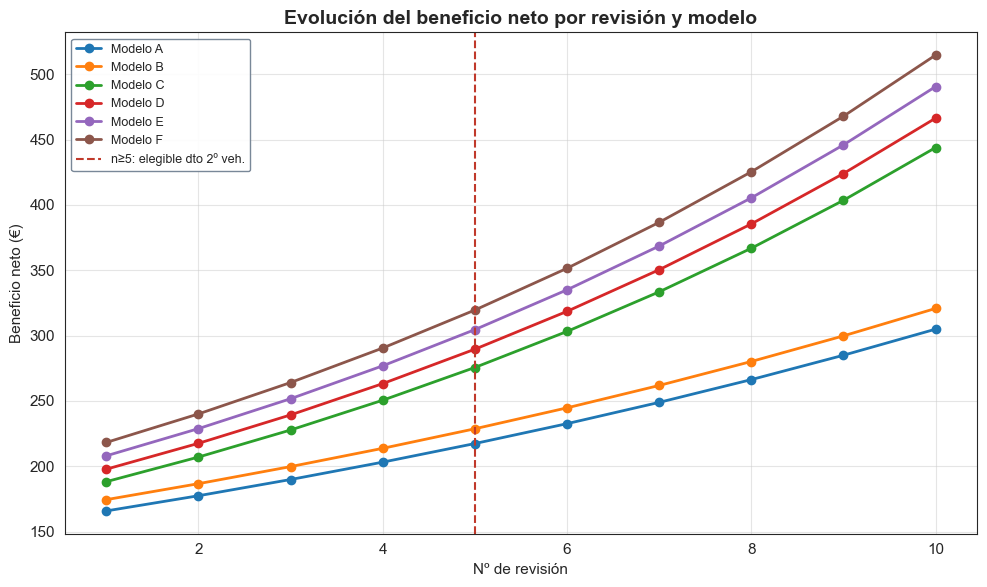

In [16]:
# Visualizar la curva de ingresos por modelo
fig, ax = plt.subplots(figsize=(10, 6))

for modelo in modelos_unicos[:6]:  # top 6 para no saturar
    subset = df_rev[df_rev['Modelo'] == modelo]
    ax.plot(subset['Revisión'], subset['Beneficio neto'], 'o-', lw=2, label=f'Modelo {modelo}')

ax.axvline(x=5, color=UAX_RED, linestyle='--', lw=1.5, label='n≥5: elegible dto 2º veh.')
ax.set_xlabel('Nº de revisión')
ax.set_ylabel('Beneficio neto (€)')
ax.set_title('Evolución del beneficio neto por revisión y modelo')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()


A partir de la revisión 5, los ingresos por mantenimiento son lo suficientemente altos como para que un descuento de 1.000€ en segundo vehículo sea una inversión rentable si el cliente tiene CLTV medio-alto.


### 8.1 Pack de Fidelización por 5 Revisiones

Para los clientes de **bajo/muy bajo riesgo con alto valor** (ya fidelizados y rentables), el objetivo es consolidar la lealtad a largo plazo con un incentivo para completar el ciclo de 5 revisiones y, eventualmente, la renovación del vehículo.

**Condiciones de elegibilidad** (se activa cuando el cliente alcanza n=5):
- Segmento: `BAJO` o `MUY_BAJO` riesgo + `Alto` valor
- Pack 5 revisiones con **−10% de descuento** sobre el precio acumulado
- **Bono de 1.000€** aplicable a la compra de un segundo vehículo

**Lógica económica:**
- Ingreso acumulado revisiones 1–5 = Σ C(n) para n = 1..5
- Precio pack = ingreso × 0.90
- Beneficio neto pack = precio_pack × 0.62
- El pack es rentable si `beneficio_neto > 1.000€` (coste del bono)

In [17]:
# ── Pack fidelización: clientes elegibles y economía por modelo ─
elegibles = df[
    (df['riesgo'].isin(['BAJO', 'MUY_BAJO'])) & (df['valor'] == 'Alto')
].copy()

print(f'Clientes elegibles para pack 5 revisiones: {len(elegibles):,}')
print(f'  CLTV medio:    {elegibles["CLTV"].mean():,.0f} €')
print(f'  p_churn media: {elegibles["p_churn"].mean():.3f}\n')

DESCUENTO_PACK    = 0.10   # −10% sobre precio acumulado
BONO_2DO_VEHICULO = 1000   # €

pack_economics = []
for modelo in sorted(elegibles['Modelo_letra'].unique()):
    base  = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)

    ingreso_5rev    = sum(base * (1 + alpha) ** n for n in range(1, 6))
    precio_pack     = ingreso_5rev * (1 - DESCUENTO_PACK)
    beneficio_neto  = precio_pack * MARGEN_NETO_PCT
    margen_tras_bono = beneficio_neto - BONO_2DO_VEHICULO
    n_clientes      = (elegibles['Modelo_letra'] == modelo).sum()

    pack_economics.append({
        'Modelo':                  modelo,
        'Ingreso 5 rev (€)':       round(ingreso_5rev, 0),
        'Precio pack −10% (€)':    round(precio_pack, 0),
        'Beneficio neto (€)':      round(beneficio_neto, 0),
        'Tras bono 1.000€ (€)':    round(margen_tras_bono, 0),
        'Rentable':                '✓ Sí' if margen_tras_bono > 0 else '✗ No',
        'Clientes elegibles':      n_clientes,
    })

df_pack = pd.DataFrame(pack_economics)
display(df_pack)

n_rentables = df_pack[df_pack['Rentable'] == '✓ Sí']['Clientes elegibles'].sum()
print(f'\nTotal clientes elegibles con pack rentable: {n_rentables:,}')
print(f'  → Estos clientes recibirán la oferta del pack cuando alcancen su 5ª revisión.')


Clientes elegibles para pack 5 revisiones: 3,236
  CLTV medio:    1,743 €
  p_churn media: 0.124



,Modelo,Ingreso 5 rev (€),Precio pack −10% (€),Beneficio neto (€),Tras bono 1.000€ (€),Rentable,Clientes elegibles
0,A,1538.0,1384.0,858.0,-142.0,✗ No,113
1,B,1618.0,1456.0,903.0,-97.0,✗ No,525
2,C,1854.0,1668.0,1034.0,34.0,✓ Sí,97
3,D,1948.0,1753.0,1087.0,87.0,✓ Sí,677
4,E,2048.0,1843.0,1143.0,143.0,✓ Sí,25
5,H,2371.0,2134.0,1323.0,323.0,✓ Sí,16
6,I,2491.0,2242.0,1390.0,390.0,✓ Sí,1352
7,J,2619.0,2357.0,1461.0,461.0,✓ Sí,424
8,K,2753.0,2478.0,1536.0,536.0,✓ Sí,7



Total clientes elegibles con pack rentable: 2,598
  → Estos clientes recibirán la oferta del pack cuando alcancen su 5ª revisión.


## 9. Exportar resultados


In [18]:
# Tabla final de clientes con acciones
output_cols = [
    'CODE', 'Modelo_letra', 'PVP_original', 'p_churn', 'riesgo', 'valor',
    'segmento', 'tasa_respuesta', 'CLTV', 'accion', 'descripcion_accion',
    'coste_efectivo_contacto', 'coste_efectivo_adicional',
    'coste_efectivo_descuento', 'coste_efectivo_marketing',
    'coste_accion', 'CLTV_con_accion', 'ganancia_cltv', 'ROI',
]

df_export = df[output_cols].copy()
df_export = df_export.sort_values('CLTV', ascending=False)

df_export.to_csv('data/warehouse/clientes_acciones_comerciales.csv', index=False)
print(f'✓ Exportado: data/warehouse/clientes_acciones_comerciales.csv ({len(df_export):,} filas)')
df_export.head(10)


✓ Exportado: data/warehouse/clientes_acciones_comerciales.csv (10,000 filas)


,CODE,Modelo_letra,PVP_original,p_churn,riesgo,valor,segmento,tasa_respuesta,CLTV,accion,descripcion_accion,coste_efectivo_contacto,coste_efectivo_adicional,coste_efectivo_descuento,coste_efectivo_marketing,coste_accion,CLTV_con_accion,ganancia_cltv,ROI
3741,SYN003741,J,34448,0.032424,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3461.991866,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3532.475452,28.193434,13.714736
1522,SYN001522,I,26002,0.026621,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3414.356430,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.6324,1.8324,3471.434226,22.831118,11.459680
6074,SYN006074,I,28161,0.028301,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3378.827042,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.6324,1.8324,3438.876237,24.019678,12.108316
5084,SYN005084,I,23798,0.028933,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3365.572922,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.6324,1.8324,3426.721316,24.459358,12.348263
2892,SYN002892,I,27310,0.029602,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3351.608903,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.6324,1.8324,3413.909878,24.920390,12.599864
9966,SYN009966,J,30246,0.038247,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3339.120134,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3419.294461,32.069731,15.737855
5386,SYN005386,J,30892,0.040833,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3286.044141,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3370.268074,33.689573,16.583284
1431,SYN001431,J,32990,0.040892,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3284.829250,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3369.144893,33.726257,16.602431
649,SYN000649,J,34133,0.040986,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3282.929117,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3367.388108,33.783597,16.632357
6240,SYN006240,J,31208,0.041081,MUY_BAJO,Alto,MUY_BAJO riesgo / Alto valor,0.4,3281.004492,Upselling,Oferta ext. garantía / seguro batería,0.2,0.0,0.0,1.7160,1.9160,3365.608569,33.841631,16.662647


## 10. Resumen ejecutivo


In [19]:
print('=' * 70)
print('RESUMEN EJECUTIVO — PLAN DE ACCIONES COMERCIALES')
print('=' * 70)
print(f'')
print(f'Clientes analizados:        {len(df):>8,}')
print(f'CLTV medio:                 {df["CLTV"].mean():>8,.0f} €')
print(f'CLTV total (cartera):       {df["CLTV"].sum():>8,.0f} €')
print(f'')
print(f'Inversión propuesta:        {df["coste_accion"].sum():>8,.0f} €')
print(f'Ganancia CLTV esperada:     {df["ganancia_cltv"].sum():>8,.0f} €')
print(f'Beneficio neto:             {df["ganancia_cltv"].sum() - df["coste_accion"].sum():>8,.0f} €')
print(f'')

clientes_con_accion = (df['coste_accion'] > 0).sum()
print(f'Clientes con acción activa: {clientes_con_accion:>8,} ({clientes_con_accion/len(df)*100:.1f}%)')
print(f'Clientes sin acción/coste:  {len(df) - clientes_con_accion:>8,} ({(len(df)-clientes_con_accion)/len(df)*100:.1f}%)')
print(f'')
print(f'ROI medio (acciones con coste): {df.loc[df["coste_accion"] > 0, "ROI"].mean():.1f}x')
print('=' * 70)


RESUMEN EJECUTIVO — PLAN DE ACCIONES COMERCIALES

Clientes analizados:          10,000
CLTV medio:                      847 €
CLTV total (cartera):       8,465,018 €

Inversión propuesta:         171,749 €
Ganancia CLTV esperada:      696,970 €
Beneficio neto:              525,221 €

Clientes con acción activa:   10,000 (100.0%)
Clientes sin acción/coste:         0 (0.0%)

ROI medio (acciones con coste): 10.9x


### Decisiones clave

1. **Concentrar la inversión** en clientes de alto riesgo + alto valor (retención agresiva) — es donde el ROI es mayor.
2. **No gastar** en clientes de bajo valor — el coste de retención no se justifica.
3. **Upselling** a clientes de bajo riesgo y alto valor — ya se van a quedar, aprovechar para vender más.
4. **Monitorizar** a los clientes de medio riesgo — si suben de riesgo, escalar la acción.
5. **Activar el descuento de 2º vehículo** cuando los clientes alcancen la 5ª revisión y tengan CLTV medio-alto.
